In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['wilhelm_spiritus_ufer'].sum())
header = 'wilhelm_spiritus_ufer'

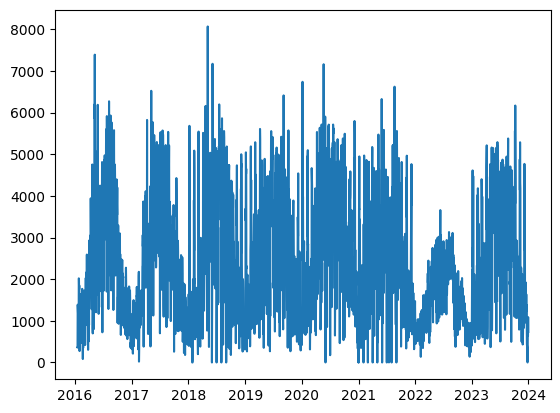

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [4]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

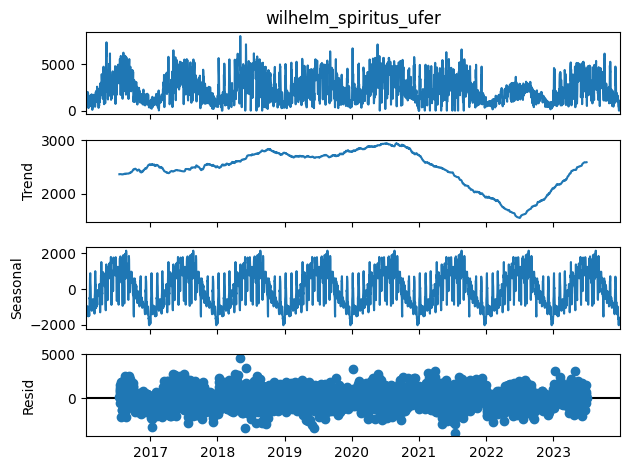

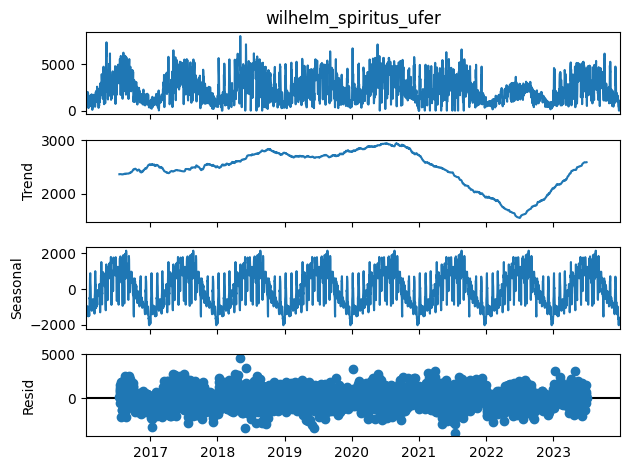

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.3874
p-value = 0.0114


In [7]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [8]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [9]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -8.6422
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_9424\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


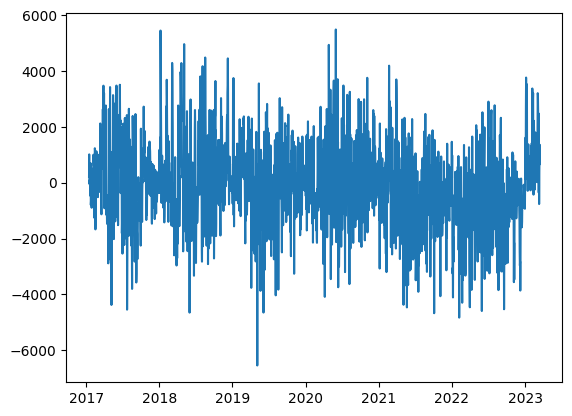

In [10]:
plt.plot(df_train.loc[:,'differences'] )

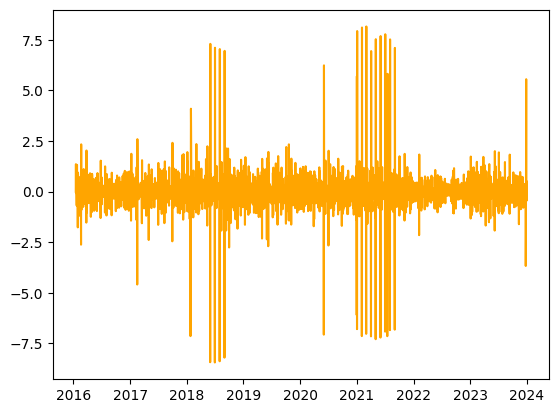

In [11]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [12]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -21.5631
P-value = 0.0000


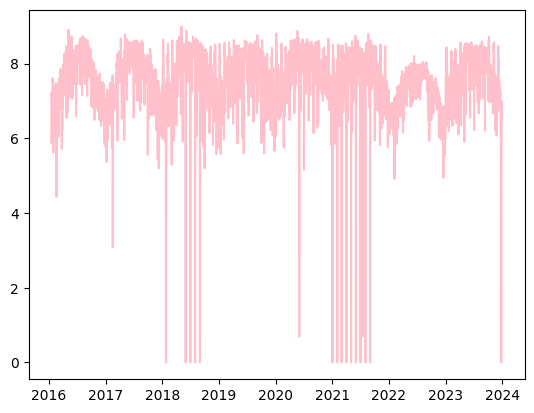

In [13]:
plt.plot(df['log'], color='pink')

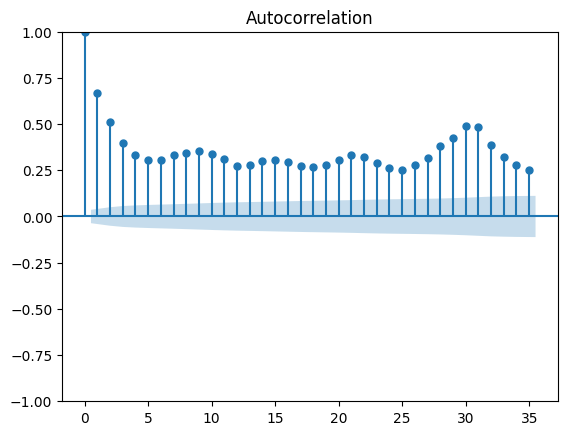

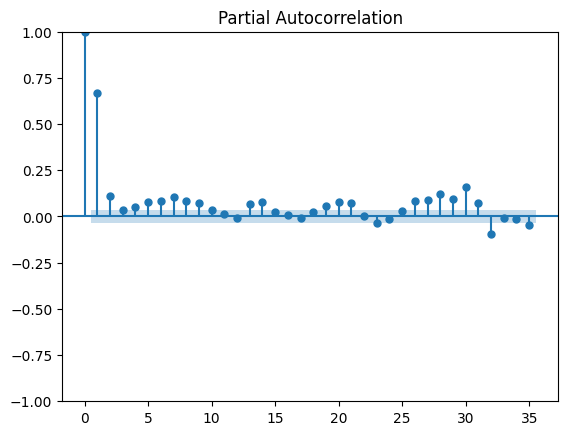

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [16]:
def ma_arima():
    for i in range(1, 7):
        p, d, q = i, 1, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='orange', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 50' if x <= 50 else '> 50')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 50']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -3503.8412, AIC: 7011.6824


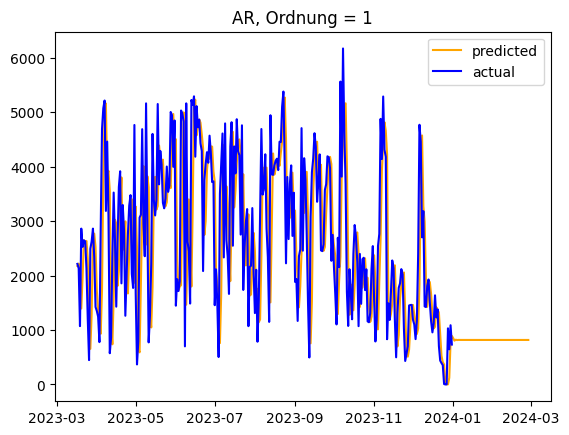

mean absolute error (mae): ARIMA: 2742.4428, simple: 913.6172
mean squared error (mse): ARIMA: 9491545.9986, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.5270, simple: 0.5388
Log Likelihood: -3453.8055, AIC: 6913.6109


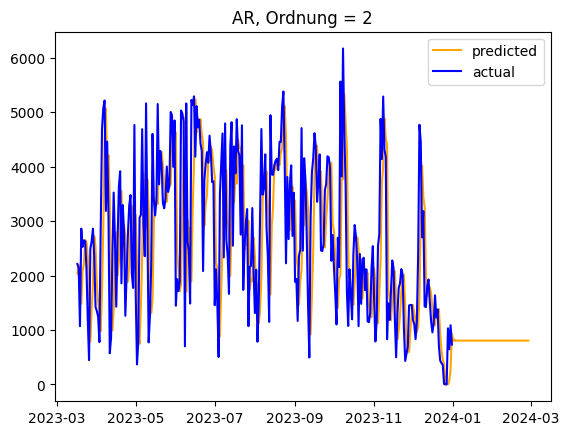

mean absolute error (mae): ARIMA: 2742.4440, simple: 913.6172
mean squared error (mse): ARIMA: 9491631.8330, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6097, simple: 0.5388
Log Likelihood: -3418.9932, AIC: 6845.9865


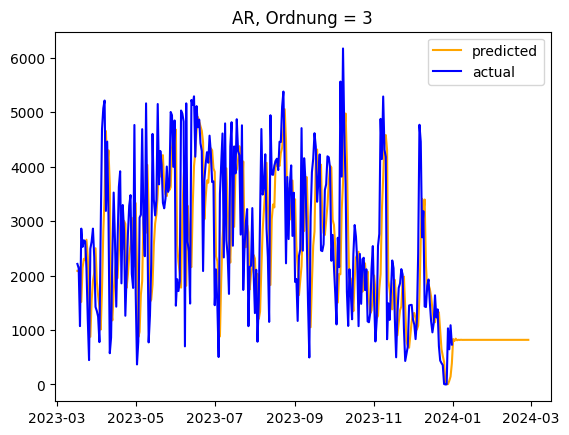

mean absolute error (mae): ARIMA: 2742.4443, simple: 913.6172
mean squared error (mse): ARIMA: 9491664.6414, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6449, simple: 0.5388
Log Likelihood: -3371.1163, AIC: 6752.2326


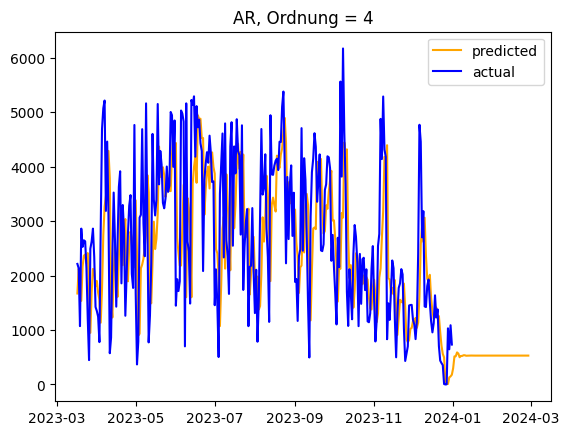

mean absolute error (mae): ARIMA: 2742.4421, simple: 913.6172
mean squared error (mse): ARIMA: 9491710.3672, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6687, simple: 0.5388
Log Likelihood: -3332.9356, AIC: 6677.8711


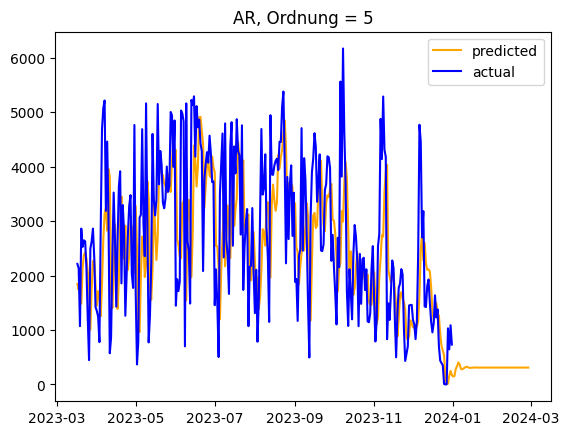

mean absolute error (mae): ARIMA: 2742.4377, simple: 913.6172
mean squared error (mse): ARIMA: 9491731.7614, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6526, simple: 0.5388
Log Likelihood: -3311.9021, AIC: 6637.8043


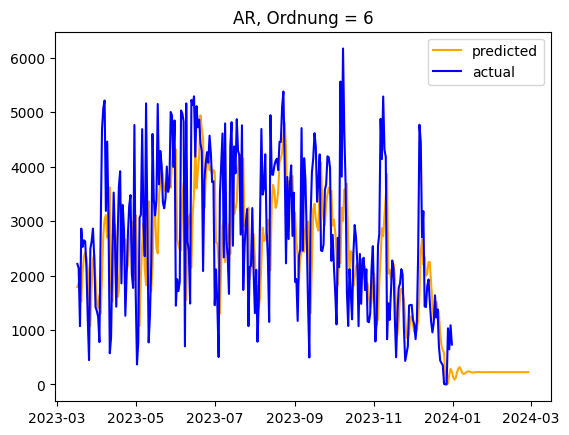

mean absolute error (mae): ARIMA: 2742.4337, simple: 913.6172
mean squared error (mse): ARIMA: 9491731.8293, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6245, simple: 0.5388
Log Likelihood: -3292.2432, AIC: 6600.4864


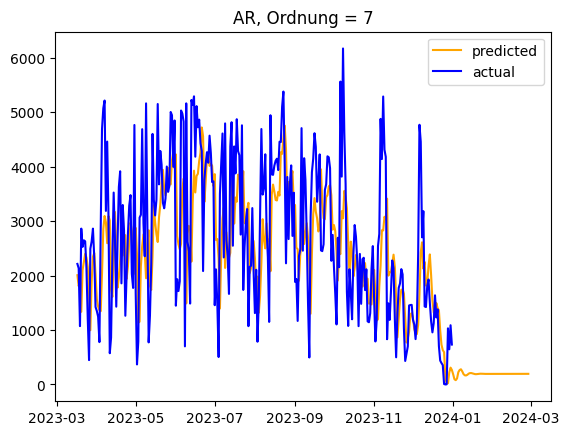

mean absolute error (mae): ARIMA: 2742.4316, simple: 913.6172
mean squared error (mse): ARIMA: 9491714.2328, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6033, simple: 0.5388


In [17]:
for i in range(1, 8):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='orange', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 50' if x <= 50 else '> 50')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 50']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [18]:
df_r

,wilhelm_spiritus_ufer,scaled,log,differences,predicted_mean,crossings
2016-01-16,361.000000,361.955261,5.891521,NaN,NaN,NaN
2016-01-17,358.000000,358.955633,5.883199,NaN,NaN,NaN
2016-01-18,1387.000000,1387.828108,7.235495,NaN,NaN,NaN
2016-01-19,1279.000000,1279.841492,7.154492,NaN,NaN,NaN
2016-01-20,1199.000000,1199.851407,7.089953,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,195.370377,NaN,NaN,NaN,5.279879,195.370377
2024-02-25,195.368297,NaN,NaN,NaN,5.279869,195.368297
2024-02-26,195.366463,NaN,NaN,NaN,5.279859,195.366463
2024-02-27,195.365745,NaN,NaN,NaN,5.279856,195.365745


Log Likelihood: -3503.8412, AIC: 7011.6824


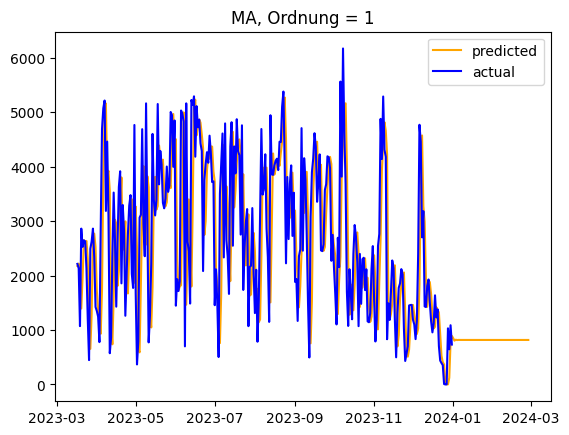

mean absolute error (mae): ARIMA: 2742.4428, simple: 913.6172
mean squared error (mse): ARIMA: 9491545.9986, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.5270, simple: 0.5388
Log Likelihood: -3453.8055, AIC: 6913.6109


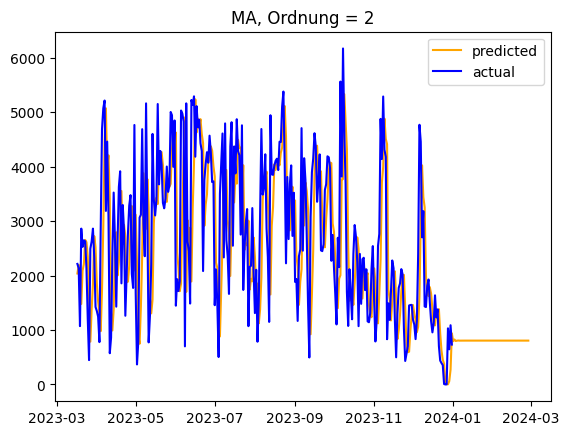

mean absolute error (mae): ARIMA: 2742.4440, simple: 913.6172
mean squared error (mse): ARIMA: 9491631.8330, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6097, simple: 0.5388
Log Likelihood: -3418.9932, AIC: 6845.9865


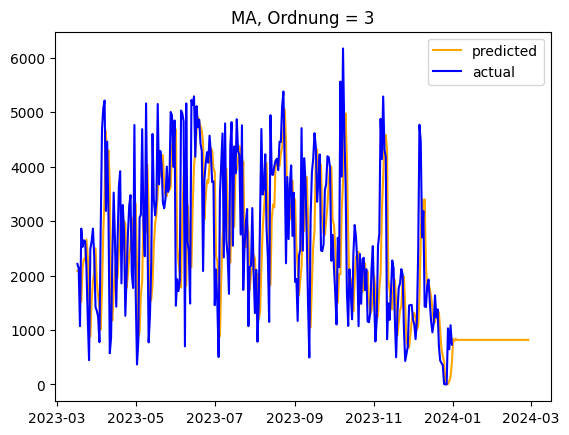

mean absolute error (mae): ARIMA: 2742.4443, simple: 913.6172
mean squared error (mse): ARIMA: 9491664.6414, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6449, simple: 0.5388
Log Likelihood: -3371.1163, AIC: 6752.2326


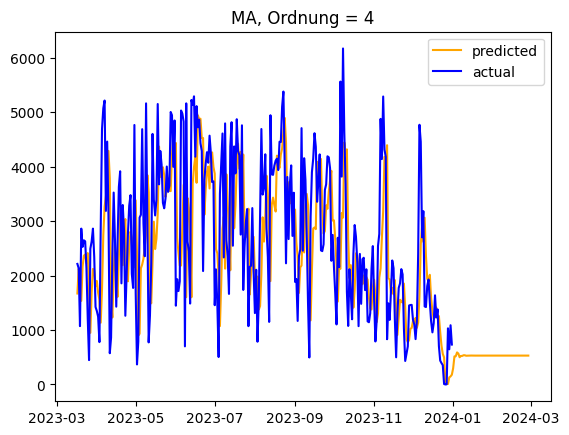

mean absolute error (mae): ARIMA: 2742.4421, simple: 913.6172
mean squared error (mse): ARIMA: 9491710.3672, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6687, simple: 0.5388
Log Likelihood: -3332.9356, AIC: 6677.8711


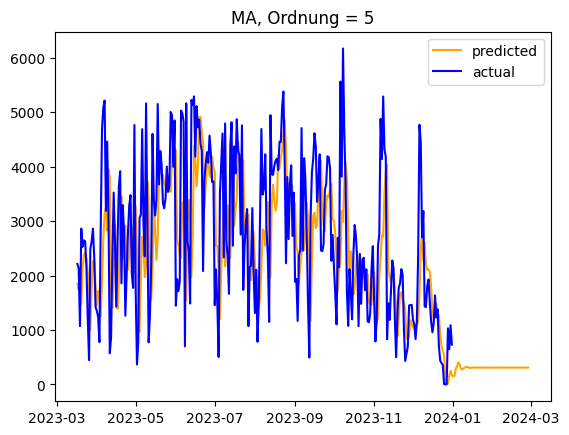

mean absolute error (mae): ARIMA: 2742.4377, simple: 913.6172
mean squared error (mse): ARIMA: 9491731.7614, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6526, simple: 0.5388
Log Likelihood: -3311.9021, AIC: 6637.8043


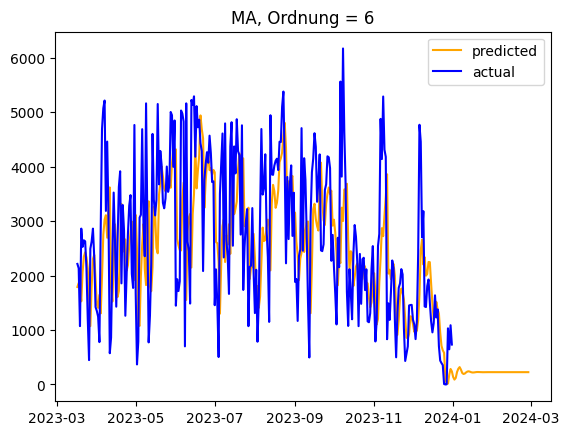

mean absolute error (mae): ARIMA: 2742.4337, simple: 913.6172
mean squared error (mse): ARIMA: 9491731.8293, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.6245, simple: 0.5388


In [19]:
ma_arima()

Log Likelihood: -3214.4097, AIC: 6434.8195


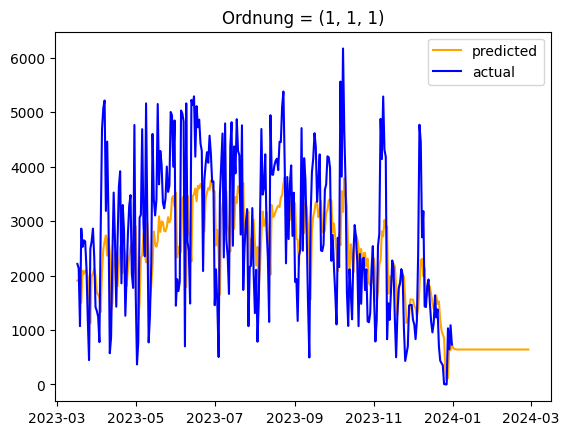

mean absolute error (mae): ARIMA: 2742.4155, simple: 913.6172
mean squared error (mse): ARIMA: 9491774.3538, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.4194, simple: 0.5388
Log Likelihood: -3211.0980, AIC: 6430.1961


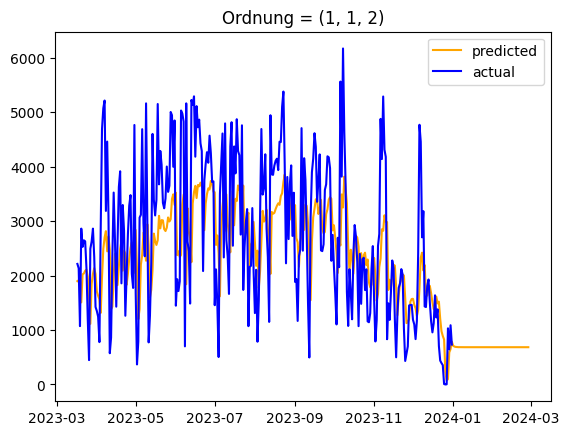

mean absolute error (mae): ARIMA: 2742.4179, simple: 913.6172
mean squared error (mse): ARIMA: 9491780.3981, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.4203, simple: 0.5388
Log Likelihood: -3206.1974, AIC: 6422.3947


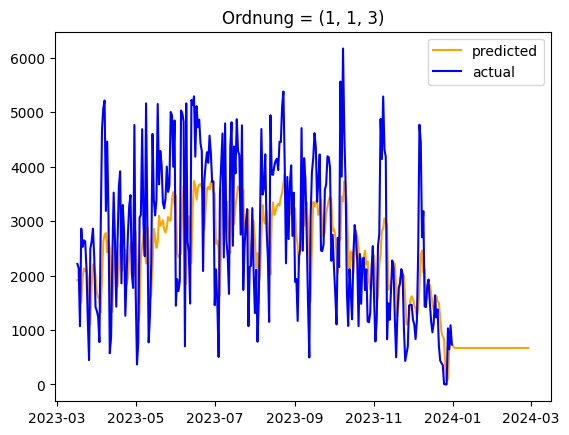

mean absolute error (mae): ARIMA: 2742.4163, simple: 913.6172
mean squared error (mse): ARIMA: 9491767.3419, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.3818, simple: 0.5388
Log Likelihood: -3204.3089, AIC: 6420.6179


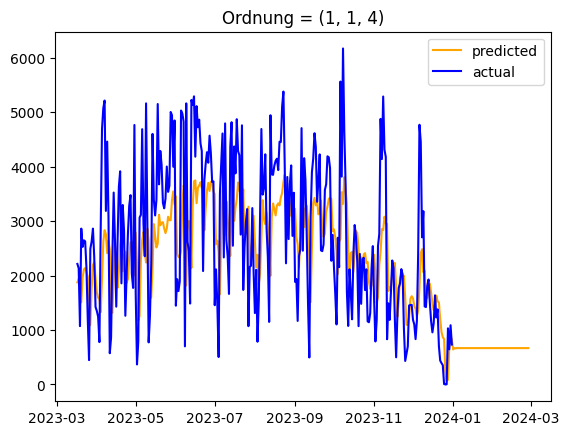

mean absolute error (mae): ARIMA: 2742.4160, simple: 913.6172
mean squared error (mse): ARIMA: 9491767.6102, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.3889, simple: 0.5388
Log Likelihood: -3204.9064, AIC: 6423.8129


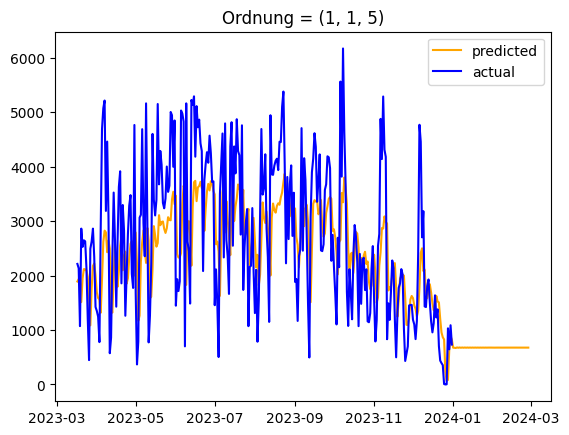

mean absolute error (mae): ARIMA: 2742.4165, simple: 913.6172
mean squared error (mse): ARIMA: 9491767.7125, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.3911, simple: 0.5388
Log Likelihood: -3202.1016, AIC: 6420.2031


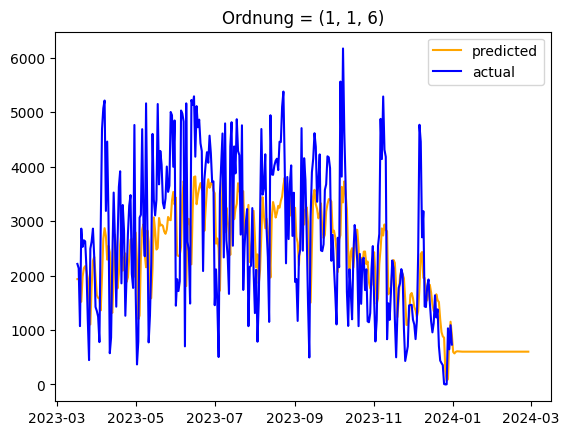

mean absolute error (mae): ARIMA: 2742.4122, simple: 913.6172
mean squared error (mse): ARIMA: 9491753.4751, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.4179, simple: 0.5388
Log Likelihood: -3202.1351, AIC: 6422.2702


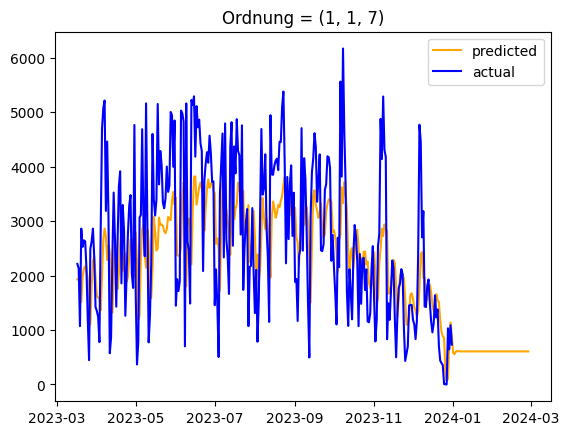

mean absolute error (mae): ARIMA: 2742.4126, simple: 913.6172
mean squared error (mse): ARIMA: 9491755.8715, simple: 1570037.9621
mean absolute percentage error (mape): ARIMA: 0.4113, simple: 0.5388


In [20]:
for i in range(1, 8):
    p, d, q = 1, 1, i

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('Ordnung = (1, 1, {:.0f})'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='orange', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 50' if x <= 50 else '> 50')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 50']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))